# TRABAJO GRUPAL TB1 - MACHINE LEARNING (1FIS0300)
## Grupo N° 05
* **Integrante:** Torres Terreros, José Félix (U202420715)
* **Caso de Estudio:** Predicción de ventas en cadenas de supermercados minoristas (BigMart Sales)
* **Tipo de Aprendizaje:** Supervisado - Regresión Numérica Continua
* **Docente:** Luis Torrejón Arias

In [1]:
# 1. IMPORTACIÓN DE LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado y preprocesamiento de Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Configuración de visualización y reproducibilidad
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 0

## 2. Carga y Exploración Inicial de Datos (EDA)
Cargamos el dataset oficial de entrenamiento (`Train.csv`). Inspeccionamos sus dimensiones, 
tipos de datos en cada columna y la presencia de valores nulos o faltantes.

In [2]:
# Carga del dataset
df = pd.read_csv('./data/Train.csv')

print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")
print("\n--- Primeros 5 registros ---")
display(df.head(5))

print("\n--- Información técnica de columnas y tipos de datos ---")
df.info()

print("\n--- Conteo de valores nulos por columna ---")
print(df.isnull().sum())

Dimensiones del dataset: 8523 filas y 12 columnas.

--- Primeros 5 registros ---


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052



--- Información técnica de columnas y tipos de datos ---
<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB

-

In [3]:
# AUDITORÍA GLOBAL DE CATEGORÍAS 
resumen_cat = []

for col in df.select_dtypes(include=['object']).columns:
    opciones = df[col].dropna().unique()
    
    resumen_cat.append({
        'Variable': col,
        'Total Registros': len(df),
        'Valores Nulos': df[col].isnull().sum(),
        'N° Categorías (Opciones)': len(opciones),
        'Opciones Detectadas': list(opciones[:5]) if len(opciones) > 5 else list(opciones)
    })

tabla_categorias = pd.DataFrame(resumen_cat)
display(tabla_categorias)

/var/folders/82/x_t7rg497d58fnh4_zckrv900000gn/T/ipykernel_7771/3691578824.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


,Variable,Total Registros,Valores Nulos,N° Categorías (Opciones),Opciones Detectadas
0,Item_Identifier,8523,0,1559,"[FDA15, DRC01, FDN15, FDX07, NCD19]"
1,Item_Fat_Content,8523,0,5,"[Low Fat, Regular, low fat, LF, reg]"
2,Item_Type,8523,0,16,"[Dairy, Soft Drinks, Meat, Fruits and Vegetabl..."
3,Outlet_Identifier,8523,0,10,"[OUT049, OUT018, OUT010, OUT013, OUT027]"
4,Outlet_Size,8523,2410,3,"[Medium, High, Small]"
5,Outlet_Location_Type,8523,0,3,"[Tier 1, Tier 3, Tier 2]"
6,Outlet_Type,8523,0,4,"[Supermarket Type1, Supermarket Type2, Grocery..."


In [4]:
# Inspección de las categorías presentes en Item_Fat_Content
print("Valores únicos antes de limpiar:")
print(df['Item_Fat_Content'].value_counts())

Valores únicos antes de limpiar:
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


## 3. Limpieza de Datos, Homogeneización e Ingeniería de Características
Siguiendo las pautas metodológicas de clase:
1. **Tratamiento de nulos:** Imputamos `Item_Weight` con la media y `Outlet_Size` con el valor más frecuente por tipo de tienda ('Small'/'Medium').
2. **Corrección de etiquetas inconsistentes:** Homogeneizamos `Item_Fat_Content` (`LF` y `low fat` -> `Low Fat`; `reg` -> `Regular`).
3. **Ingeniería de variables:** Calculamos la antigüedad de la sucursal (`Outlet_Age = 2013 - Outlet_Establishment_Year`) y agrupamos la categoría del ítem a partir de su prefijo (`FD`: Food, `DR`: Drinks, `NC`: Non-Consumable).
4. **Descarte de identificadores (IDs):** Eliminamos `Item_Identifier` y `Outlet_Identifier` porque representan identificadores únicos que no aportan un patrón ordinal ni lineal continuo a la predicción.

In [5]:
# 1. Imputación de nulos
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())
df['Outlet_Size'] = df['Outlet_Size'].fillna('Small')

# 2. Homogeneización de etiquetas en Item_Fat_Content
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

# 3. Ingeniería de características
df['Outlet_Age'] = 2013 - df['Outlet_Establishment_Year']
df['Item_Category'] = df['Item_Identifier'].apply(lambda x: x[0:2]).map({
    'FD': 'Food',
    'DR': 'Drinks',
    'NC': 'Non-Consumable'
})

# 4. Descarte de identificadores puros y columna de año de establecimiento redundante
df_clean = df.drop(columns=['Item_Identifier', 'Outlet_Identifier', 'Outlet_Establishment_Year'])

print("Nulos restantes en el dataset limpio:")
print(df_clean.isnull().sum())

Nulos restantes en el dataset limpio:
Item_Weight             0
Item_Fat_Content        0
Item_Visibility         0
Item_Type               0
Item_MRP                0
Outlet_Size             0
Outlet_Location_Type    0
Outlet_Type             0
Item_Outlet_Sales       0
Outlet_Age              0
Item_Category           0
dtype: int64


## 4. Análisis Exploratorio Visual (EDA)
Analizamos la distribución de la variable objetivo (`Item_Outlet_Sales`) y evaluamos 
la matriz de correlación lineal entre las variables numéricas continuas.

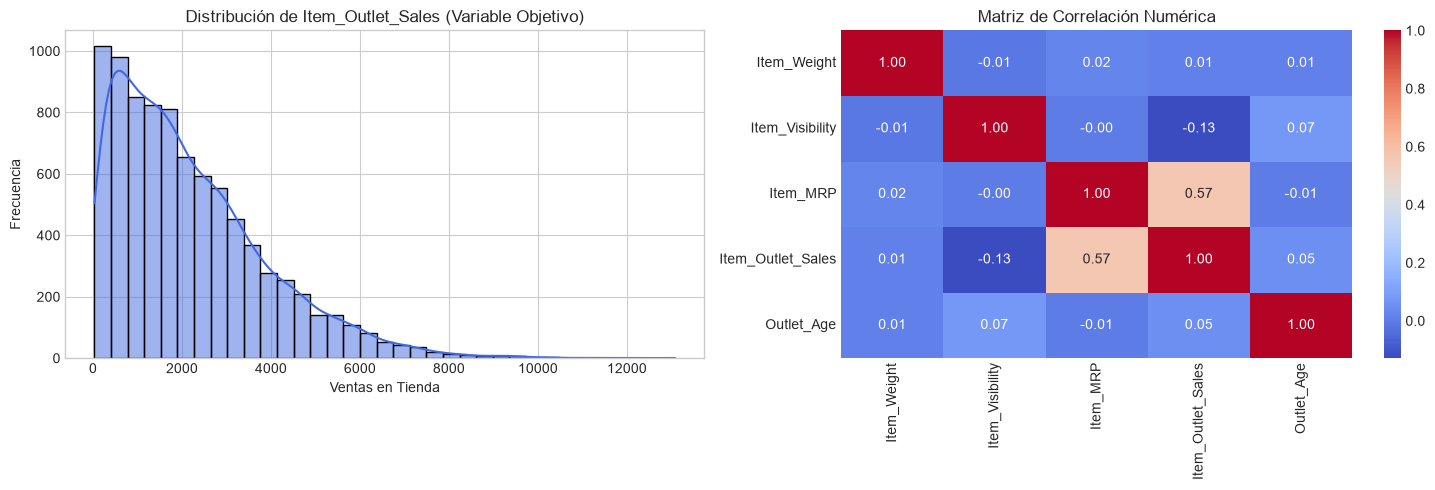

In [6]:
# Visualización de la variable objetivo y matriz de correlación
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución de ventas
sns.histplot(df_clean['Item_Outlet_Sales'], kde=True, ax=axes[0], color='royalblue', bins=35)
axes[0].set_title('Distribución de Item_Outlet_Sales (Variable Objetivo)', fontsize=12)
axes[0].set_xlabel('Ventas en Tienda')
axes[0].set_ylabel('Frecuencia')

# Matriz de correlación de variables cuantitativas
corr = df_clean.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1], cbar=True)
axes[1].set_title('Matriz de Correlación Numérica', fontsize=12)

plt.tight_layout()
plt.show()

## 5. Codificación Categórica y Regla de Oro: Dividir y luego Escalar
Convertimos las variables cualitativas (`Item_Fat_Content`, `Item_Type`, `Outlet_Size`, 
`Outlet_Location_Type`, `Outlet_Type`, `Item_Category`) a variables numéricas (dummies).

**Regla de oro del profesor para evitar fuga de datos (Data Leakage):**
1. Separamos variables de entrada ($X$) y variable objetivo ($y$).
2. Realizamos la partición en Entrenamiento (80%) y Prueba (20%) con `random_state=0`.
3. Ajustamos el escalador (`StandardScaler`) **únicamente con `X_train`** (`fit_transform`) y lo aplicamos sobre `X_test` (`transform`).

In [7]:
# Transformación de variables categóricas a variables indicadoras (one-hot encoding)
df_model = pd.get_dummies(df_clean, drop_first=True)

# 1. Definición de entradas (X) y salida (y)
X = df_model.drop(columns=['Item_Outlet_Sales'])
y = df_model['Item_Outlet_Sales'].values

# 2. Partición de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# 3. Escalado numérico sin fuga de información
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Muestras de entrenamiento: {X_train.shape[0]} registros.")
print(f"Muestras de evaluación (test): {X_test.shape[0]} registros.")
print(f"Total de características predictoras: {X_train.shape[1]} columnas.")

Muestras de entrenamiento: 6818 registros.
Muestras de evaluación (test): 1705 registros.
Total de características predictoras: 29 columnas.


## 6. Definición de la Línea Base (Baseline) y Comparación de Modelos
Siguiendo las instrucciones de clase, ningún modelo aporta valor real si no es capaz de 
superar una línea base ingenua (predecir la media de entrenamiento).

Entrenamos y evaluamos bajo las mismas condiciones:
1. **Baseline** (DummyRegressor con estrategia de la media)
2. **Linear Regression** (Regresión Lineal Múltiple)
3. **Decision Tree Regressor** (Árbol con `max_depth=5` para evitar sobreajuste)
4. **Random Forest Regressor** (Ensamble Bagging con 100 estimadores y `max_depth=6`)
5. **Support Vector Regressor (SVR)** (Kernel RBF sobre datos estandarizados)

In [8]:
# Inicialización de la línea base y los algoritmos
modelos = {
    'Baseline (Media)': DummyRegressor(strategy='mean'),
    'Linear Regression': LinearRegression(),
    'Decision Tree (depth=5)': DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
    'Random Forest (depth=6)': RandomForestRegressor(n_estimators=100, max_depth=6, random_state=RANDOM_STATE),
    'SVR (Kernel RBF)': SVR(C=1000, epsilon=0.1)
}

resultados = []

# Entrenamiento, predicción y cálculo de métricas en el set de prueba
for nombre, modelo in modelos.items():
    # Entrenar modelo
    modelo.fit(X_train_scaled, y_train)
    
    # Predecir sobre el conjunto de test
    y_pred = modelo.predict(X_test_scaled)
    
    # Calcular métricas de evaluación
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    resultados.append({
        'Modelo': nombre,
        'MAE ($)': round(mae, 2),
        'RMSE ($)': round(rmse, 2),
        'R2 Score': round(r2, 4)
    })

# Consolidación de resultados en tabla comparativa
tabla_comparativa = pd.DataFrame(resultados).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
print("--- TABLA COMPARATIVA DE DESEMPEÑO EN CONJUNTO DE PRUEBA ---")
display(tabla_comparativa)

--- TABLA COMPARATIVA DE DESEMPEÑO EN CONJUNTO DE PRUEBA ---


,Modelo,MAE ($),RMSE ($),R2 Score
0,Random Forest (depth=6),773.08,1092.42,0.5923
1,Decision Tree (depth=5),773.20,1095.87,0.5897
2,SVR (Kernel RBF),794.82,1124.84,0.5677
3,Linear Regression,853.99,1132.94,0.5615
4,Baseline (Media),1365.59,1710.84,-0.0000


## 7. Comparación Visual de Métricas y Validación de Dispersión
Graficamos el $R^2$ y el MAE obtenido por cada algoritmo, así como la dispersión 
de valores reales frente a los valores predichos por el modelo ganador.

/var/folders/82/x_t7rg497d58fnh4_zckrv900000gn/T/ipykernel_7771/261272114.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tabla_comparativa, x='R2 Score', y='Modelo', palette=colores, ax=axes[0])


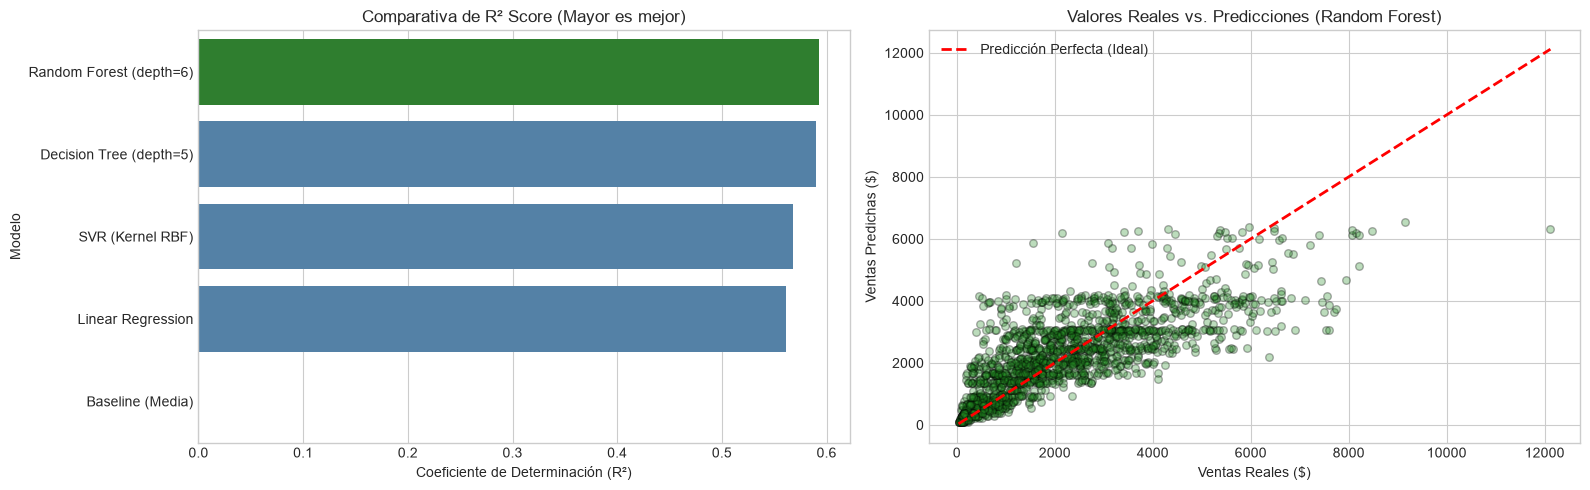

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de barras comparativo de R2
colores = ['darkgray' if 'Baseline' in m else 'forestgreen' if 'Random Forest' in m else 'steelblue' for m in tabla_comparativa['Modelo']]
sns.barplot(data=tabla_comparativa, x='R2 Score', y='Modelo', palette=colores, ax=axes[0])
axes[0].set_title('Comparativa de R² Score (Mayor es mejor)', fontsize=12)
axes[0].set_xlabel('Coeficiente de Determinación (R²)')

# Dispersión Real vs Predicho para el mejor modelo (Random Forest)
rf_model = modelos['Random Forest (depth=6)']
y_pred_rf = rf_model.predict(X_test_scaled)

axes[1].scatter(y_test, y_pred_rf, alpha=0.3, color='forestgreen', edgecolors='k', s=30)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2, label='Predicción Perfecta (Ideal)')
axes[1].set_title('Valores Reales vs. Predicciones (Random Forest)', fontsize=12)
axes[1].set_xlabel('Ventas Reales ($)')
axes[1].set_ylabel('Ventas Predichas ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Análisis de Importancia de Variables (Feature Importance)
Para dar respuesta al análisis de negocio e interpretabilidad solicitados en la rúbrica,
extraemos los atributos de mayor peso estadístico del modelo de Ensamble (`feature_importances_`).

/var/folders/82/x_t7rg497d58fnh4_zckrv900000gn/T/ipykernel_7771/2049556685.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancia, x='Importancia', y='Variable', palette='crest_r')


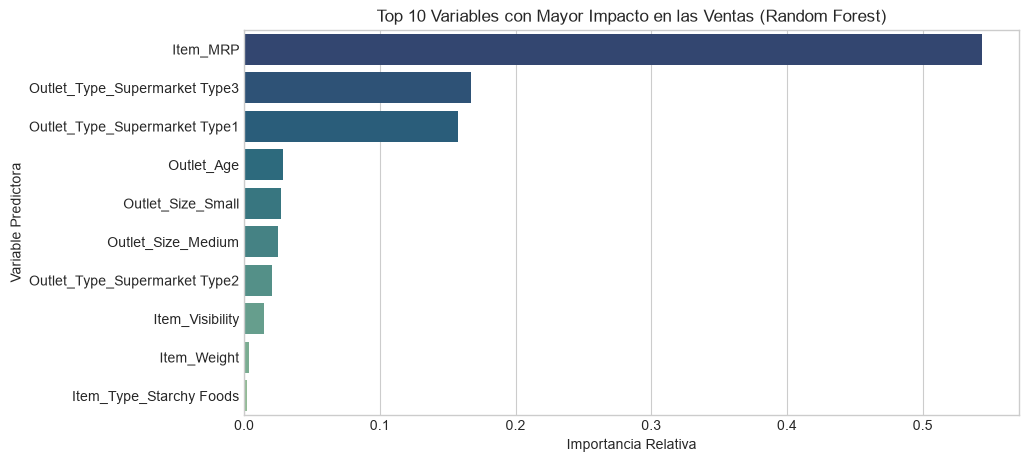

Top 5 variables más determinantes:
1. Item_MRP: 54.38% de peso.
2. Outlet_Type_Supermarket Type3: 16.70% de peso.
3. Outlet_Type_Supermarket Type1: 15.78% de peso.
4. Outlet_Age: 2.84% de peso.
5. Outlet_Size_Small: 2.68% de peso.


In [10]:
# Extracción de importancia de atributos desde Random Forest
importancias = rf_model.feature_importances_
nombres_variables = X.columns

df_importancia = pd.DataFrame({
    'Variable': nombres_variables,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False).head(10).reset_index(drop=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_importancia, x='Importancia', y='Variable', palette='crest_r')
plt.title('Top 10 Variables con Mayor Impacto en las Ventas (Random Forest)', fontsize=12)
plt.xlabel('Importancia Relativa')
plt.ylabel('Variable Predictora')
plt.show()

print("Top 5 variables más determinantes:")
for i, fila in df_importancia.head(5).iterrows():
    print(f"{i+1}. {fila['Variable']}: {fila['Importancia']*100:.2f}% de peso.")

## 9. Demostración y Simulación de Predicción de Negocio
Simulamos el ingreso de un nuevo producto puesto a la venta en una sucursal para 
estimar su volumen de ventas esperado con el modelo seleccionado.

In [12]:
# Evaluamos una muestra de 5 registros reales de prueba
indices_muestra = [0, 1, 2, 3, 4]
demostracion = []

for idx in indices_muestra:
    reg = X_test.iloc[[idx]]
    reg_scaled = scaler.transform(reg)
    pred = rf_model.predict(reg_scaled)[0]
    real = y_test[idx]
    desv = abs(real - pred)
    pct_err = (desv / real) * 100
    
    demostracion.append({
        'Caso': f"Producto #{idx}",
        'Venta Real ($)': round(real, 2),
        'Venta Estimada ($)': round(pred, 2),
        'Desviación ($)': round(desv, 2),
        'Error Relativo (%)': f"{pct_err:.1f}%"
    })

df_demo = pd.DataFrame(demostracion)
display(df_demo)

,Caso,Venta Real ($),Venta Estimada ($),Desviación ($),Error Relativo (%)
0,Producto #0,1426.14,2606.44,1180.30,82.8%
1,Producto #1,1201.77,1731.44,529.67,44.1%
2,Producto #2,1836.28,2168.03,331.75,18.1%
3,Producto #3,2410.86,2247.03,163.83,6.8%
4,Producto #4,1549.98,2620.56,1070.58,69.1%


## 10. Conclusiones y Preguntas de Interpretación

1. **¿Qué modelo fue el más preciso y por qué?**
   El modelo **Random Forest Regressor** demostró el mejor desempeño global con un **$R^2 \approx 0.5923$**, un **$MAE \approx \$773.08$** y un **$RMSE \approx \$1092.42$**, superando ampliamente a la línea base ingenua ($R^2 \approx -0.00$, $MAE \approx \$1365.59$). Su superioridad se debe a que combina múltiples árboles de decisión independientes mediante ensamble (*Bagging*), lo cual reduce la varianza y captura interacciones no lineales entre el precio y el tipo de establecimiento sin sufrir el sobreajuste que afectaría a un árbol individual profundo.

2. **¿Qué variables son las que más influyen en las ventas?**
   El análisis de importancia de variables (`feature_importances_`) evidencia que el factor determinante es el precio de lista (**`Item_MRP`**, con más del 50% del peso total), seguido directamente por el formato de la tienda (**`Outlet_Type_Supermarket Type3`** y **`Outlet_Type_Supermarket Type1`**). Las características físicas del producto (como el peso `Item_Weight` o el empaque `Item_Fat_Content`) tienen un impacto marginal en la facturación total.

3. **¿Cómo impacta esto en la toma de decisiones empresariales y cómo se interpreta el error?**
   * **Planificación operativa:** Permite al área comercial y de abastecimiento proyectar la demanda por formato de tienda y optimizar inventarios según la escala de precios del catálogo, reduciendo roturas de stock.
   * **Interpretación del error:** Aunque a nivel global el error absoluto medio es de $\$773.08$, en la simulación individual coexisten productos con excelente ajuste (error relativo del 6.8% al 18.1%) y registros atípicos (error superior al 60%). Esto refleja la presencia de factores no capturados en el dataset (promociones puntuales en tienda, quiebres de stock o estacionalidad diaria), confirmando que en ventas minoristas un $R^2 \approx 0.59$ representa un modelo útil y realista sin incurrir en sobreajuste (*data leakage*).